In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("TCS Historical Data.csv", parse_dates=["Date"], index_col="Date")

# Keep only Close price
df = df[['Price']]

print(df.head())

              Price
Date               
2024-10-09  4252.95
2024-10-08  4253.25
2024-10-07  4272.85
2024-10-04  4252.25
2024-10-03  4232.75


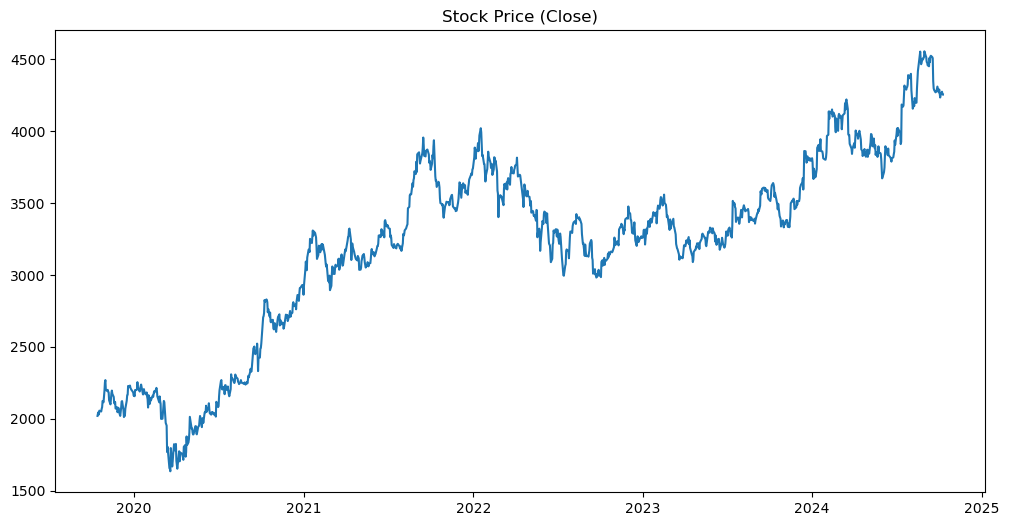

In [2]:
plt.figure(figsize=(12,6))
plt.plot(df['Price'])
plt.title("Stock Price (Close)")
plt.show()

In [3]:
df['diff'] = df['Price'].diff()
df = df.dropna()

In [4]:
df

,Price,diff
Date,,
2024-10-08,4253.25,0.30
2024-10-07,4272.85,19.60
2024-10-04,4252.25,-20.60
2024-10-03,4232.75,-19.50
2024-10-01,4287.90,55.15
...,...,...
2019-10-18,2057.35,5.95
2019-10-17,2030.95,-26.40
2019-10-16,2046.40,15.45


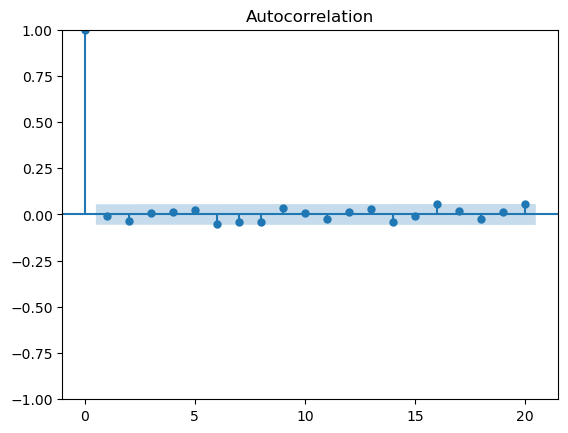

In [5]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['diff'], lags=20)
plt.show()

In [12]:
from statsmodels.tsa.arima.model import ARIMA

# MA(1) model
model = ARIMA(df['Price'], order=(0,1,1))  # d=1 because we differenced
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 1240
Model:                 ARIMA(0, 1, 1)   Log Likelihood               -6500.324
Date:                Wed, 22 Apr 2026   AIC                          13004.647
Time:                        13:26:34   BIC                          13014.891
Sample:                             0   HQIC                         13008.500
                               - 1240                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0071      0.027     -0.267      0.790      -0.059       0.045
sigma2      2114.5477     54.130     39.064      0.000    2008.455    2220.640
Ljung-Box (L1) (Q):                   0.00   Jarque-

C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PYTHON\anaconda3\Lib\

In [13]:
forecast = model_fit.forecast(steps=5)
print(forecast)

1240    2021.115894
1241    2021.115894
1242    2021.115894
1243    2021.115894
1244    2021.115894
Name: predicted_mean, dtype: float64


C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


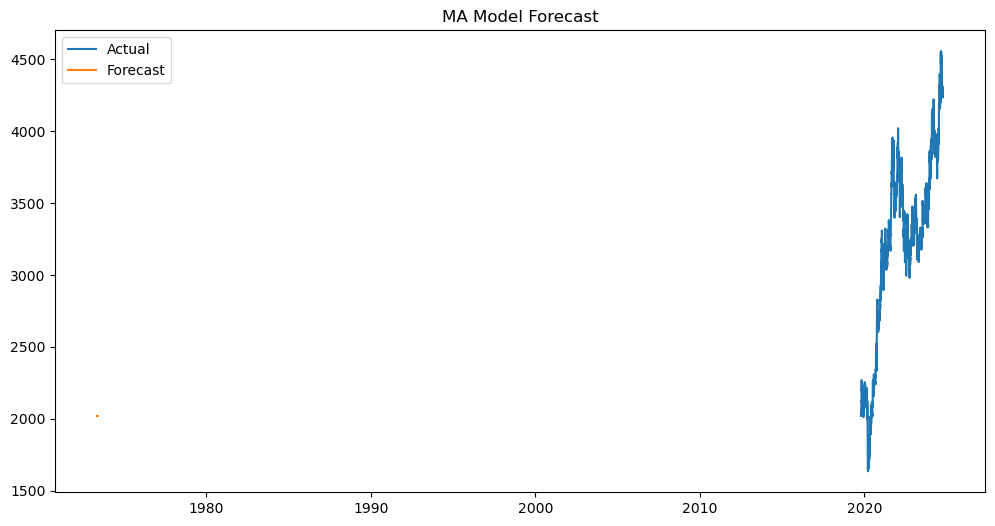

In [14]:
plt.figure(figsize=(12,6))
plt.plot(df['Price'], label="Actual")
plt.plot(forecast, label="Forecast")
plt.legend()
plt.title("MA Model Forecast")
plt.show()